In [1]:
import numpy as np
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import Tensor
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim
from tqdm import tqdm
from scipy.special import gamma as gamma_function
from scipy import stats

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [3]:
def fwd_pass(net, X:Tensor, y:Tensor, device, optimizer, train=False):
    """
    This function controls the machine learning steps, depending on if we are in training mode or not.
    """
    if train:
        net.train()
        net.zero_grad()
    outputs = net(X.to(device))
    loss = F.mse_loss(outputs, y.to(device)).to(device)
    if train:
        loss.backward()
        optimizer.step()
    return loss

def train(net, traindata, testdata, batchsize:int, epochs:int, device, optimizer):
    """
    Trains the model for the number of epochs specified, using the batch size specified.
    Returns a dataframe with the stats from the training.
    """
    dataset = DataLoader(traindata, batchsize, shuffle=True)
    df_labels = ["Loss", "Validation loss", "Epoch", "Iteration"]
    df_data = [[0], [0], [0], [0]]
    df = pd.DataFrame(dict(zip(df_labels, df_data)))
    i = 0
    for epoch in tqdm(range(epochs)):
        for data in dataset:
            i = i+1
            X, y = data
            #print(X[0], y[0])
            loss = fwd_pass(net, X, y, device, optimizer, train=True)
            #acc, loss = test(net, testdata, size=size)
            if i % 10 == 0:
                val_loss = test(net, testdata, device, optimizer, batchsize)
                df_data = [float(loss), float(val_loss), epoch, i]
                new_df = pd.DataFrame(dict(zip(df_labels, df_data)), index=[0])
                df = pd.concat([df, new_df], ignore_index=True)
            
    return df

def test(net, data, device, optimizer, size:int = 32):
    """
    Calculates the accuracy and the loss of the model for a random batch.
    """
    net.eval()
    dataset = DataLoader(data, size, shuffle=True) #shuffle data and choose batch size
    X, y = next(iter(dataset)) #get a random batch
    val_loss = fwd_pass(net, X, y, device, optimizer, train=False)
    return val_loss
    
def predict(net, testdata, size:int, device):
    """
    Calculates the accuracy and the loss of the model in testing mode.
    If return_loss is True, it will return the loss for each datapoint.
    It can also return the softmax values of the raw output from the model.
    Does not shuffle the data.
    """
    dataset = DataLoader(testdata, size, shuffle=False) #shuffle data and choose batch size
    input = torch.zeros((len(dataset), size))
    prediction = torch.zeros((len(dataset), size))
    truth = torch.zeros((len(dataset), size))
    i = 0
    net.eval()
    with torch.no_grad():
        for data in tqdm(dataset):
            X, y = data
            input[i] = X
            outputs = net(X.to(device))
            prediction[i] = outputs
            truth[i] = y
            i = i+1
    return torch.flatten(input), torch.flatten(truth), torch.flatten(prediction)

In [4]:
class SequentialNet(nn.Module):

    def __init__(self, activation:str, in_channels:int, out_channels:int, L: int = 1024, n_hidden:int = 1):
        
        assert activation in ["relu", "tanh"], "should be a a valid activation function"
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(in_channels, L))
        for i in range(n_hidden):
            layers.append(nn.Linear(L, L))
            if activation == "relu":
                layers.append(nn.ReLU())
            elif activation == "tanh":
                layers.append(nn.Tanh())
        layers.append(nn.Linear(L, out_channels))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [5]:
def plot_experiment(df):
    fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(12,4), layout="constrained")
    sn.histplot(df, x="A_est", bins=30, ax = axs[0][0], stat="probability")
    axs[0][0].plot([df["A_est"].mean()]*2, [0, 1], color="red", linewidth=2, label="Average")
    axs[0][0].plot([df["a"].mean()]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="True value")
    axs[0][0].legend()
    axs[0][0].set_xlabel(r"$\hat{A}$")

    sn.histplot(df, x="B_est", bins=30, ax = axs[0][1], stat="probability")
    axs[0][1].plot([df["B_est"].mean()]*2, [0, 1], color="red", linewidth=2, label="Average")
    axs[0][1].plot([df["b"].mean()]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="True value")
    axs[0][1].set_xlabel(r"$\hat{B}$")

    sn.histplot(df, x="var_est", bins=30, ax = axs[0][2], stat="probability")
    axs[0][2].plot([df["var_est"].mean()]*2, [0, 1], color="red", linewidth=2, label="Average")
    axs[0][2].plot([df["var"].mean()]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="True value")
    axs[0][2].set_xlabel(r"$\hat{\sigma}^2$")

    sn.histplot(df, x="efficiency_95CI_mu", bins=30, ax = axs[1][0], stat="probability")
    axs[1][0].plot([df["efficiency_95CI_mu"].mean()]*2, [0, 1], color="red", linewidth=2, label="Average")
    axs[1][0].plot([0.95]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.95")
    axs[1][0].set_xlabel(r"Fraction $\mu$ within 95% CI")
    axs[1][0].legend()
    
    sn.histplot(df, x="efficiency_95CI_y", bins=30, ax = axs[1][1], stat="probability")
    axs[1][1].plot([df["efficiency_95CI_y"].mean()]*2, [0, 1], color="red", linewidth=2, label="Average")
    axs[1][1].plot([0.95]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.95")
    axs[1][1].set_xlabel(r"Fraction y within 95% CI")
    axs[1][1].set_xlim(0.8, 1)

    sn.histplot(df, x="efficiency_90CI_y", bins=30, ax = axs[1][2], stat="probability")
    axs[1][2].plot([df["efficiency_90CI_y"].mean()]*2, [0, 1], color="red", linewidth=2, label="Average")
    axs[1][2].plot([0.90]*2, [0, 1], color="black", linewidth=2, linestyle="--", label="0.90")
    axs[1][2].set_xlabel(r"Fraction y within 90% CI")
    axs[1][2].set_xlim(0.8, 1)
    
    for ax in axs.flatten():
        ax.set_ylabel("Frequency")
        ax.set_ylim(0, 0.2)
    
    axs[1][0].set_ylim(0, 0.9)
    axs[1][1].set_ylim(0, 0.3)
    axs[1][2].set_ylim(0, 0.3)

In [6]:
def plot_predictions(df): 
    fig, axs = plt.subplots(ncols=2, figsize=(9,4))
    sn.scatterplot(df, x="x", y="y", ax=axs[0], label="Sampled values")
    axs[0].fill_between(df["x"], df["95CI_exp_y_lower"], df["95CI_exp_y_upper"], label=r"95% CI $\mu$", color="red", alpha=0.4)
    sn.lineplot(df, x="x", y="y_est", color="red",linewidth=2, label="Estimated values", ax=axs[0])
    sn.lineplot(df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label="Long run values", ax=axs[0])

    sn.scatterplot(df, x="x", y="y", ax=axs[1], label="Sampled values")
    axs[1].fill_between(df["x"], df["95CI_y_lower"], df["95CI_y_upper"], label=r"95% CI y", color="red", alpha=0.4)
    sn.lineplot(df, x="x", y="y_est", color="red",linewidth=2, label="Estimated values", ax=axs[1])
    sn.lineplot(df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label="Long run values", ax=axs[1])
    for ax in axs:
        ax.grid(True)

In [7]:
def generate_linear_data(x_min, x_max, a, b, sigma, N=1000):
    rng = np.random.default_rng()
    epsilons = rng.normal(0, sigma, N)
    x = np.linspace(x_min, x_max, num=N)
    mu = a + b*x
    y = mu + epsilons
    return x, y, mu

def generate_nonlinear_data(x_min, x_max, a, b, sigma, N=1000):
    rng = np.random.default_rng()
    epsilons = rng.normal(0, sigma, N)
    x = np.linspace(x_min, x_max, num=N)
    mu = a + b*x + 0.1*x**2 #+ sigma/3*np.sin(x)
    y = mu + epsilons
    return x, y, mu

def generate_heteroscedastic_data(x_min, x_max, a, b, sigma, c=5, N=1000):
    rng = np.random.default_rng()
    x = np.linspace(x_min, x_max, num=N)
    epsilons = rng.normal(0, 2*sigma*(np.abs(x)+1), N)
    mu = a + b*x + c*np.sin(x)
    y = mu + epsilons
    return x, y, mu

def confidence_interval_mu(data_df, alpha=0.95):
    n = len(data_df)
    t = stats.t(df=n-2).ppf((1-alpha)/2)
    sample_var = (1/len(data_df))*np.sum((data_df["y"] - data_df["y_est"])**2)
    w = t*(1/np.sqrt(n-2))*np.sqrt(n*sample_var*(1/n + (data_df["x_norm"]**2)/np.sum(data_df["x_norm"]**2)))
    return data_df["y_est"]-w, data_df["y_est"]+w

def confidence_interval_y(data_df, alpha=0.95):
    n = len(data_df)
    t = stats.t(df=n-2).ppf((1- alpha)/2)
    sample_var = (1/len(data_df))*np.sum((data_df["y"] - data_df["y_est"])**2)
    w = t*(1/np.sqrt(n-2))*np.sqrt(n*sample_var*(1 + 1/n + (data_df["x_norm"]**2)/np.sum(data_df["x_norm"]**2)))
    return data_df["y_est"]-w, data_df["y_est"]+w

In [8]:
def linear_regression(df):
    N_data = len(df)
    y_mean = df["y"].mean()
    x_mean = df["x"].mean()
    df["y_norm"] = df["y"] - y_mean
    df["x_norm"] = df["x"] - x_mean
    b_est = np.sum((df["y_norm"])*(df["x_norm"]))/np.sum(df["x_norm"]**2)
    a_est = y_mean - b_est*x_mean
    df["y_est"] = a_est + b_est*df["x"]
    sample_var = (1/N_data)*np.sum((df["y"] - df["y_est"])**2)
    df["95CI_exp_y_upper"], df["95CI_exp_y_lower"] = confidence_interval_mu(df, 0.95)
    df["95CI_y_upper"], df["95CI_y_lower"] = confidence_interval_y(df, 0.95)
    df["90CI_exp_y_upper"], df["90CI_exp_y_lower"] = confidence_interval_mu(df, 0.90)
    df["90CI_y_upper"], df["90CI_y_lower"] = confidence_interval_y(df, 0.90)
    return df, a_est, b_est, sample_var

In [9]:
def repeated_experiment(N=1000, a=2, b=0.3, var=0.5**2, N_data=100, linear=True, const_var=True):
    df = pd.DataFrame({"A_est": np.zeros(N),
                       "B_est" : np.zeros(N),
                       "sample_var" : np.zeros(N),
                       "var_est" : np.zeros(N),
                       "efficiency_CI_mu" : np.zeros(N),
                       "efficiency_CI_y" : np.zeros(N)}
                       )
    df["a"] = a
    df["b"] = b
    df["var"] = var
    for i in range(N):
        if linear:
            data_x, data_y, mu = generate_linear_data(-10, 10, a=a, b=b, sigma=np.sqrt(var), N=N_data)
        else:
            if const_var:
                data_x, data_y, mu = generate_nonlinear_data(-10, 10, a=a, b=b, sigma=np.sqrt(var), N=N_data)
            else:
                data_x, data_y, mu = generate_heteroscedastic_data(-10, 10, a=a, b=b, sigma=np.sqrt(var), N=N_data)
        data_df = pd.DataFrame({"x":data_x, "y": data_y})
        
        data_df, a_est, b_est, sample_var = linear_regression(data_df)

        # Save estimated parameter values
        df.loc[i, "A_est"] = a_est
        df.loc[i, "B_est"] = b_est
        df.loc[i, "sample_var"] = sample_var
        df.loc[i, "var_est"] = sample_var*(N_data/(N_data-2))
        
        # Add truth information
        data_df["mu_true"] = mu
        # Calculate fraction of CIs that contain true value
        mask1 = data_df["mu_true"] >= data_df["95CI_exp_y_lower"]
        mask2 = data_df["mu_true"] <= data_df["95CI_exp_y_upper"]
        df.loc[i, "efficiency_95CI_mu"] = np.sum(mask1*mask2)/N_data

        mask1 = data_df["y"] >= data_df["95CI_y_lower"]
        mask2 = data_df["y"] <= data_df["95CI_y_upper"]
        df.loc[i, "efficiency_95CI_y"] = np.sum(mask1*mask2)/N_data

        mask1 = data_df["y"] >= data_df["90CI_y_lower"]
        mask2 = data_df["y"] <= data_df["90CI_y_upper"]
        df.loc[i, "efficiency_90CI_y"] = np.sum(mask1*mask2)/N_data
        
    return df

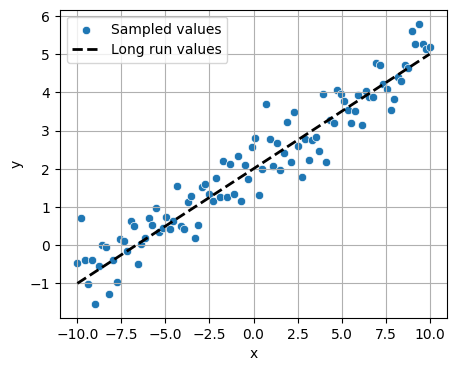

In [10]:
data_x, data_y, y_mu = generate_linear_data(-10, 10, a=2, b=0.3, sigma=0.5, N=100)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
fig, ax = plt.subplots(figsize=(5,4))
sn.scatterplot(data_df, x="x", y="y", ax=ax, label="Sampled values")
sn.lineplot(data_df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label="Long run values")
ax.grid(True)

2.0753273416265205 0.2922185580665736 0.267896521691046


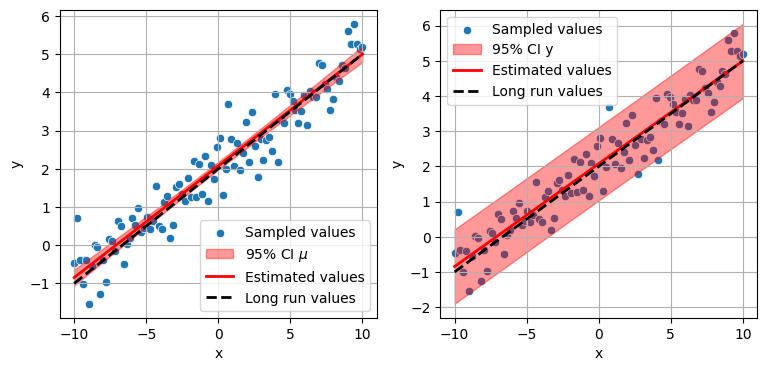

In [11]:
data_df, a_est, b_est, sample_var = linear_regression(data_df)
print(a_est, b_est, sample_var)
plot_predictions(data_df)

In [12]:
experiment1_df = repeated_experiment()
experiment1_df

,A_est,B_est,sample_var,var_est,efficiency_CI_mu,efficiency_CI_y,a,b,var,efficiency_95CI_mu,efficiency_95CI_y,efficiency_90CI_y
0,1.982373,0.301852,0.229726,0.234414,0.0,0.0,2,0.3,0.25,1.0,0.95,0.91
1,1.994821,0.299055,0.217664,0.222106,0.0,0.0,2,0.3,0.25,1.0,0.95,0.93
2,1.924889,0.298217,0.280870,0.286602,0.0,0.0,2,0.3,0.25,1.0,0.96,0.88
3,1.989817,0.305740,0.244074,0.249055,0.0,0.0,2,0.3,0.25,1.0,0.96,0.89
4,1.937665,0.311090,0.242219,0.247162,0.0,0.0,2,0.3,0.25,1.0,0.95,0.91
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2.025678,0.305343,0.234685,0.239475,0.0,0.0,2,0.3,0.25,1.0,0.98,0.92
996,1.996724,0.282408,0.261771,0.267114,0.0,0.0,2,0.3,0.25,1.0,0.98,0.88
997,1.953499,0.294825,0.252589,0.257744,0.0,0.0,2,0.3,0.25,1.0,0.96,0.91
998,1.975215,0.306024,0.297353,0.303421,0.0,0.0,2,0.3,0.25,1.0,0.94,0.92


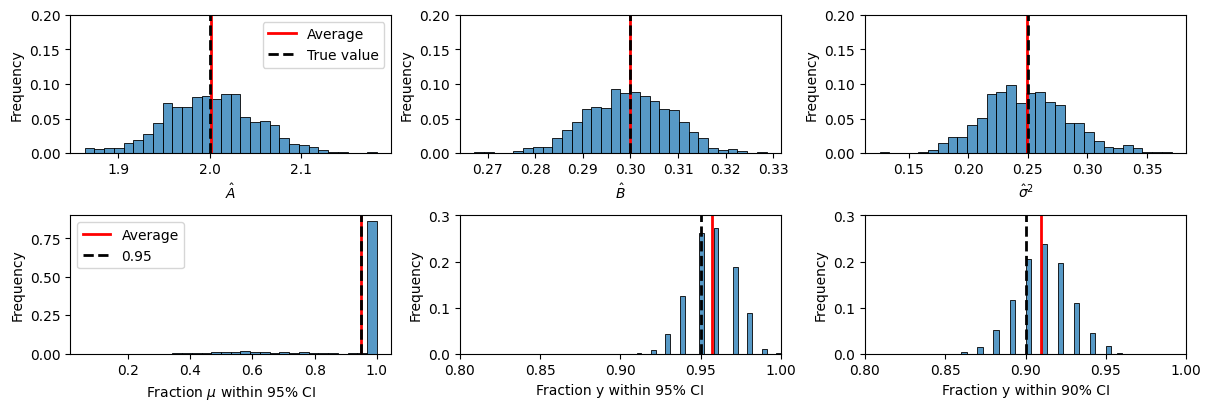

In [13]:
plot_experiment(experiment1_df)

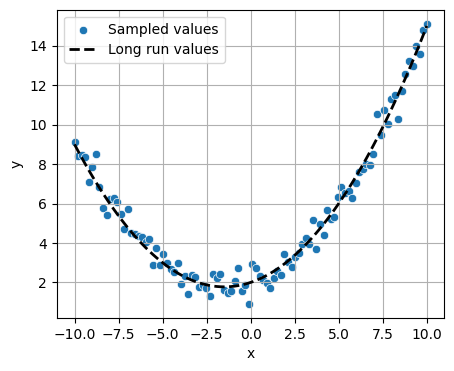

In [14]:
data_x, data_y, y_mu = generate_nonlinear_data(-10, 10, a=2, b=0.3, sigma=0.5, N=100)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
fig, ax = plt.subplots(figsize=(5,4))
sn.scatterplot(data_df, x="x", y="y", ax=ax, label="Sampled values")
sn.lineplot(data_df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label="Long run values")
ax.grid(True)

5.428793503219225 0.2894551948249917 9.680842612079505


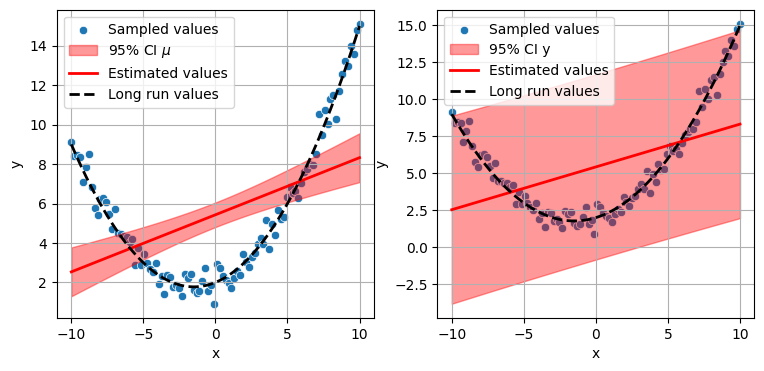

In [15]:
data_df, a_est, b_est, sample_var = linear_regression(data_df)
print(a_est, b_est, sample_var)
plot_predictions(data_df)

In [16]:
experiment2_df = repeated_experiment(linear=False, var=0.5**2)
experiment2_df

,A_est,B_est,sample_var,var_est,efficiency_CI_mu,efficiency_CI_y,a,b,var,efficiency_95CI_mu,efficiency_95CI_y,efficiency_90CI_y
0,5.419597,0.307069,9.876966,10.078537,0.0,0.0,2,0.3,0.25,0.16,0.98,0.91
1,5.387008,0.283439,9.274046,9.463312,0.0,0.0,2,0.3,0.25,0.14,1.00,0.92
2,5.401787,0.296588,9.041742,9.226268,0.0,0.0,2,0.3,0.25,0.15,0.99,0.93
3,5.392293,0.302901,9.029197,9.213466,0.0,0.0,2,0.3,0.25,0.15,0.96,0.91
4,5.439680,0.288884,9.518361,9.712614,0.0,0.0,2,0.3,0.25,0.14,0.96,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.362099,0.304818,9.740322,9.939104,0.0,0.0,2,0.3,0.25,0.15,0.96,0.91
996,5.430084,0.288902,9.886666,10.088434,0.0,0.0,2,0.3,0.25,0.15,0.97,0.94
997,5.376721,0.304580,9.499634,9.693504,0.0,0.0,2,0.3,0.25,0.15,0.98,0.92
998,5.365420,0.299513,9.399034,9.590851,0.0,0.0,2,0.3,0.25,0.14,0.96,0.92


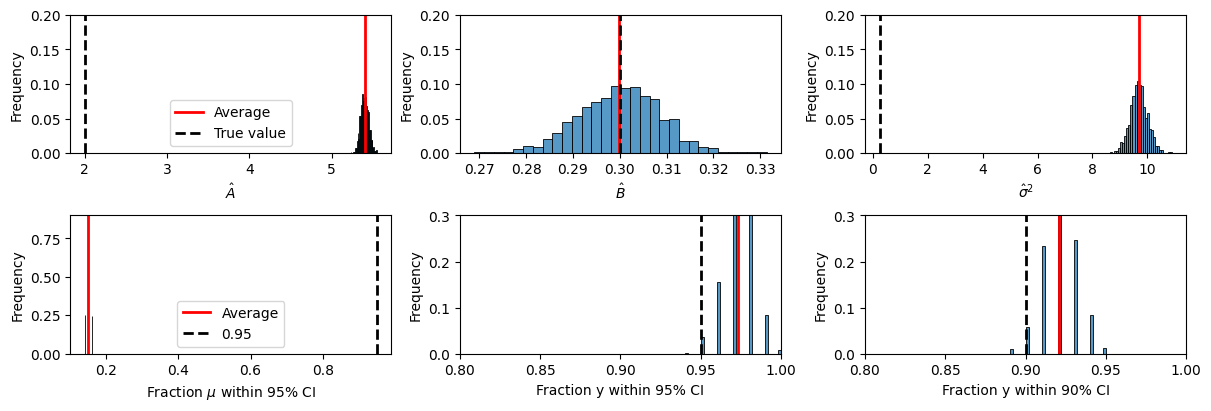

In [17]:
plot_experiment(experiment2_df)

2.0498119748442862 0.5352514338810885 1.859330352760711


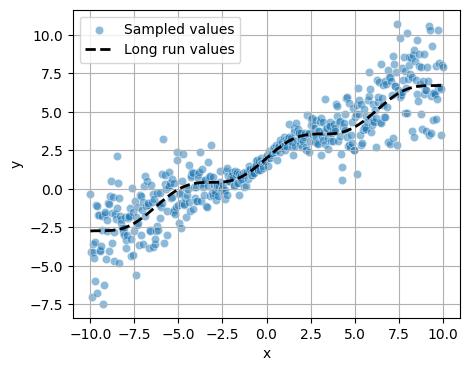

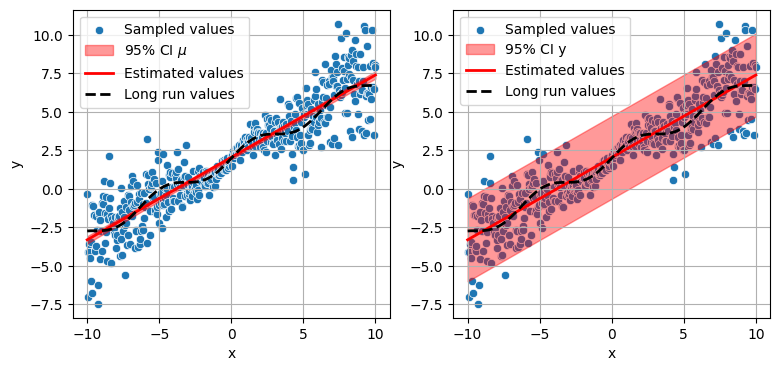

In [18]:

data_x, data_y, y_mu = generate_heteroscedastic_data(-10, 10, a=2, b=0.5, sigma=0.1, c=0.5, N=500)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
fig, ax = plt.subplots(figsize=(5,4))
sn.scatterplot(data_df, x="x", y="y", ax=ax, label="Sampled values", alpha=0.5)
sn.lineplot(data_df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label="Long run values")
ax.grid(True)
data_df, a_est, b_est, sample_var = linear_regression(data_df)
print(a_est, b_est, sample_var)
plot_predictions(data_df)

In [19]:
def train_nn(df):
    ntest = len(df)
    x = torch.tensor(df["x"]).reshape(ntest, 1).to(torch.float32)
    y = torch.tensor(df["y"]).reshape(ntest, 1).to(torch.float32)
    dset = torch.utils.data.TensorDataset(x, y)
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dset, [int(ntest-2*ntest/10), int(ntest/10), int(ntest/10)])
    print(test_dataset[0])
    
    model = SequentialNet(L=500, n_hidden=4, activation="relu", in_channels=1, out_channels=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
    training_results = train(model, train_dataset, 
                            val_dataset, batchsize=500, epochs = 20, 
                            device = device, optimizer = optimizer)
    input, target, preds = predict(model, test_dataset, 1, device)
    test_df = pd.DataFrame({"x":input, "y": target})
    test_df["y_est_NN"] = preds
    return test_df
#print(test_df)
data_x, data_y, y_mu = generate_heteroscedastic_data(-10, 10, a=2, b=0.5, sigma=0.1, c=0.5, N=5000)
data_df = pd.DataFrame({"x":data_x, "y": data_y, "y_mu": y_mu})
test_df = train_nn(data_df)
fig, ax = plt.subplots(figsize=(5,4))
sn.scatterplot(data_df, x="x", y="y", ax=ax, label="Sampled values", alpha=0.5)
sn.lineplot(test_df, x="x", y="y_est_NN", ax=ax, label="Predicted values", color="red")
sn.lineplot(data_df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label="Long run values")
ax.grid(True)

(tensor([-7.8796]), tensor([-2.8251]))


 35%|███▌      | 7/20 [02:40<04:57, 22.88s/it]


KeyboardInterrupt: 